In [1]:
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from sklearn.utils.class_weight import compute_class_weight

[HAMI-core Msg(90133:140405835353408:libvgpu.c:837)]: Initializing.....
[HAMI-core Msg(90133:140405835353408:libvgpu.c:856)]: Initialized


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*weights_only=False.*")

In [3]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=1):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gat2(x, edge_index)
        return x

In [4]:
train_data = torch.load("data/knn_train_graph.pt")
val_data = torch.load("data/knn_val_graph.pt")
test_data = torch.load("data/knn_test_graph.pt")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

In [6]:
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.cross_entropy(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.item()

In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names, fontsize=14):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     xticklabels=class_names, yticklabels=class_names,
                     annot_kws={"size": fontsize})  # font size for numbers inside boxes

    plt.xlabel('Predicted Labels', fontsize=fontsize)
    plt.ylabel('True Labels', fontsize=fontsize)
    plt.title('Confusion Matrix', fontsize=fontsize + 2)
    ax.tick_params(axis='both', labelsize=fontsize)  # font size for axis ticks
    plt.tight_layout()
    plt.show()


def plot_classification_report(y_true, y_pred, class_names, fontsize=14):
    # Get classification report as a dictionary
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )

    # Convert to DataFrame
    df = pd.DataFrame(report_dict).T

    # Drop support column and keep only precision, recall, f1-score
    df = df.drop(columns=["support"])

    # Plot heatmap
    plt.figure(figsize=(10, len(df) * 0.6))
    sns.heatmap(df, annot=True, cmap="GnBu", fmt=".2f",
                annot_kws={"size": fontsize},  # font size inside cells
                cbar_kws={"shrink": 0.6})
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title("Classification Report Heatmap", fontsize=fontsize + 2)
    plt.tight_layout()
    plt.show()

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch.nn.functional as F
import pandas as pd
import seaborn as sns

def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        prob = F.softmax(out, dim=1).cpu().numpy()
        y_true = data.y.cpu().numpy()
        y_pred = out.argmax(dim=1).cpu().numpy()

        acc = (y_pred == y_true).mean()
        report = classification_report(y_true, y_pred, digits=4, zero_division=0, output_dict=False)
        
        
        auc = roc_auc_score(y_true, prob, multi_class='ovr')
        
    return acc, report, auc, y_true, y_pred


In [9]:
in_dim = train_data.x.shape[1]
num_classes = train_data.y.max().item() + 1
model = GAT(in_channels=in_dim, hidden_channels=64, out_channels=num_classes, heads=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 550

In [10]:
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    loss = train(model, train_data, optimizer)
    val_acc, report, auc, _, _ = evaluate(model, val_data)

    train_losses.append(loss)
    val_accuracies.append(val_acc)

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")



Epoch 000 | Loss: 10.6270 | Val Acc: 0.5419
Epoch 010 | Loss: 4.1500 | Val Acc: 0.5419
Epoch 020 | Loss: 1.5797 | Val Acc: 0.5924
Epoch 030 | Loss: 1.1745 | Val Acc: 0.6218
Epoch 040 | Loss: 1.1157 | Val Acc: 0.6280
Epoch 050 | Loss: 1.0846 | Val Acc: 0.6268
Epoch 060 | Loss: 1.0506 | Val Acc: 0.6308
Epoch 070 | Loss: 1.0348 | Val Acc: 0.6339
Epoch 080 | Loss: 1.0120 | Val Acc: 0.6361
Epoch 090 | Loss: 0.9892 | Val Acc: 0.6377
Epoch 100 | Loss: 1.0073 | Val Acc: 0.6382
Epoch 110 | Loss: 0.9980 | Val Acc: 0.6382
Epoch 120 | Loss: 0.9954 | Val Acc: 0.6403
Epoch 130 | Loss: 0.9797 | Val Acc: 0.6401
Epoch 140 | Loss: 0.9718 | Val Acc: 0.6418
Epoch 150 | Loss: 0.9649 | Val Acc: 0.6415
Epoch 160 | Loss: 0.9542 | Val Acc: 0.6422
Epoch 170 | Loss: 0.9550 | Val Acc: 0.6432
Epoch 180 | Loss: 0.9508 | Val Acc: 0.6415
Epoch 190 | Loss: 0.9560 | Val Acc: 0.6441
Epoch 200 | Loss: 1.0300 | Val Acc: 0.6427
Epoch 210 | Loss: 0.9184 | Val Acc: 0.6422
Epoch 220 | Loss: 0.9613 | Val Acc: 0.6429
Epoch 230 

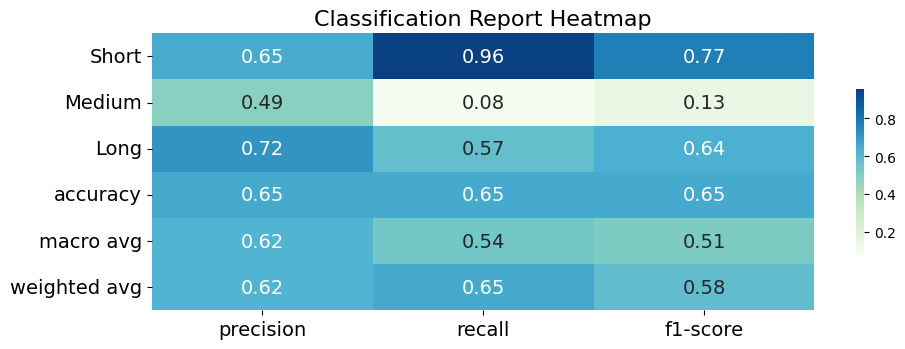

In [11]:
import matplotlib.pyplot as plt
test_acc, test_report, test_auc, y_true, y_pred = evaluate(model, test_data)
class_names=["Short", "Medium", "Long"]
plot_classification_report(y_true, y_pred, class_names)

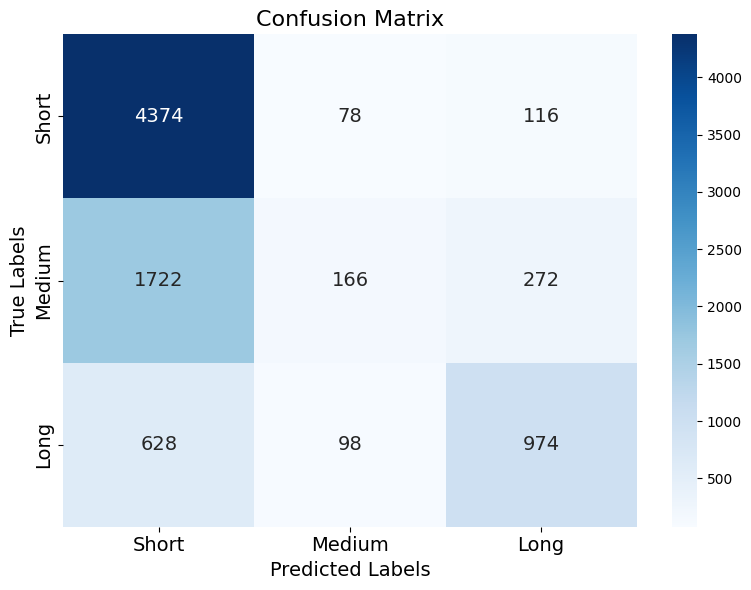

In [12]:
plot_confusion_matrix(y_true, y_pred, class_names)

In [13]:
print("Test Accuracy:", round(test_acc * 100, 2), "%")
print("\nClassification Report:\n", test_report)
print("\nTest AUC Score:", round(test_auc, 4))

Test Accuracy: 65.42 %

Classification Report:
               precision    recall  f1-score   support

           0     0.6505    0.9575    0.7747      4568
           1     0.4854    0.0769    0.1327      2160
           2     0.7151    0.5729    0.6362      1700

    accuracy                         0.6542      8428
   macro avg     0.6170    0.5358    0.5145      8428
weighted avg     0.6212    0.6542    0.5822      8428


Test AUC Score: 0.769


<Figure size 800x600 with 0 Axes>

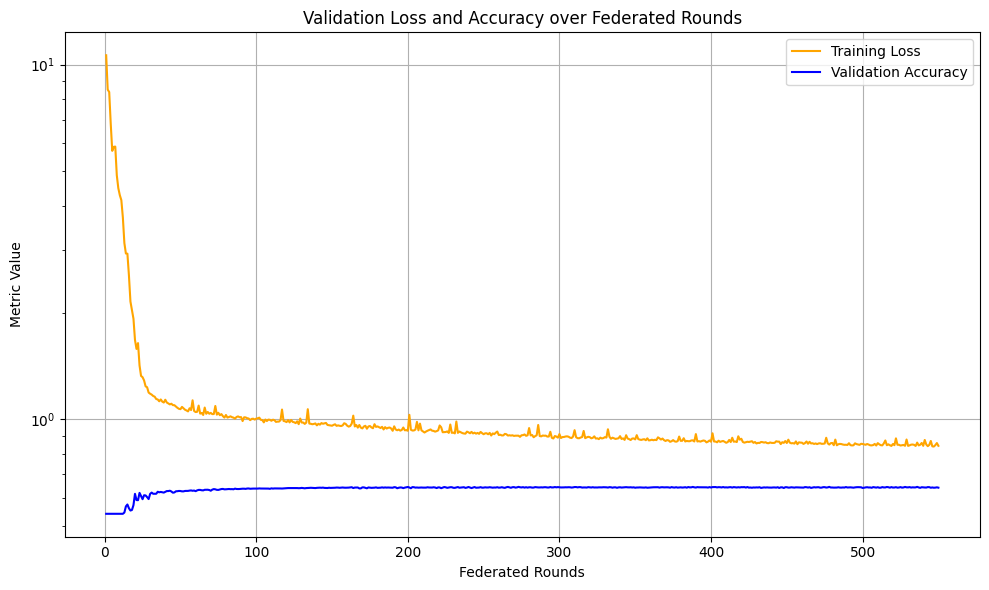

In [14]:
import matplotlib.pyplot as plt


epochs=list(range(1, len(train_losses)+1))
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, color='orange', label='Training Loss')
plt.plot(epochs, val_accuracies, color='blue', label='Validation Accuracy')

plt.title('Validation Loss and Accuracy over Federated Rounds')
plt.xlabel('Federated Rounds')
plt.ylabel('Metric Value')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()